# Sunspot: locally scaled M6

This experiment retains M6 adaptive residual-window selection and adds a general, causal local-error scale. The scale uses only point level, point-versus-last-value slope, and 12/36-step trailing difference volatility. It does not use sunspot phase or the current truth.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src').exists()), None)
if PROJECT_ROOT is None: raise RuntimeError('Cannot locate project root')
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from kf_forecasting.models.kf_enbpi import EnbPIConfig
from kf_forecasting.models.kf_out_of_time_enbpi import OutOfTimeEnbPIConfig, locally_scaled_from_fitted, run_out_of_time_enbpi
SEED, ALPHA, K = 2026, 0.05, 60

In [2]:
cols=['year','month','decimal_date','sunspot','std','observations','provisional']
d=pd.read_csv(PROJECT_ROOT/'data/raw/SN_m_tot_V2.0.csv',sep=';',header=None,names=cols)
d['date']=pd.to_datetime(dict(year=d.year,month=d.month,day=1))
series=(d.loc[d.date.between('1900-01-01','2023-01-01') & d.sunspot.ge(0)].set_index('date').sunspot.astype(float).sort_index())
train_size=int(.8*len(series)); dates=series.index[train_size:]
print(f'train={train_size}, test={len(series)-train_size}, raw scale')

train=1181, test=296, raw scale


In [3]:
fitted=run_out_of_time_enbpi(series.to_numpy(),train_size,config=OutOfTimeEnbPIConfig(base=EnbPIConfig(alpha=ALPHA,random_state=SEED)),model_name='Original adaptive M6',data_seed=SEED)
scaled=locally_scaled_from_fitted(fitted,dates,neighbours=K,support_lower=0.0)
f=fitted.forecast
baseline=pd.DataFrame({'date':dates,'method':'Original adaptive M6','truth':f.truth,'point':f.point,'lower':f.lower,'upper':f.upper})
def metrics(frame):
    y,p,l,u=(frame[c].to_numpy() for c in ['truth','point','lower','upper']); ml=y<l; mu=y>u
    return {'method':frame.method.iloc[0],'selected_window':fitted.selected_residual_window,'coverage':np.mean((y>=l)&(y<=u)),'mean_width':np.mean(u-l),'median_width':np.median(u-l),'interval_score':np.mean(u-l+2/ALPHA*((l-y)*ml+(y-u)*mu)),'negative_lower_rate':np.mean(l<0),'rmse':np.sqrt(np.mean((y-p)**2)),'mae':np.mean(abs(y-p))}
summary=pd.concat([pd.DataFrame([metrics(baseline)]),scaled.summary],ignore_index=True)
summary

,method,selected_window,coverage,mean_width,median_width,interval_score,negative_lower_rate,rmse,mae
0,Original adaptive M6,300,0.972973,97.859110,99.481183,107.377653,0.459459,19.580785,13.914650
1,Local-scale M6,None,0.959459,75.383140,66.875102,86.179497,0.263514,19.674116,14.150447
2,Local-scale M6 + support,None,0.959459,73.452451,65.436204,84.248808,0.000000,19.674116,14.150447


In [4]:
scaled.window_selection

,window,window_value,mean_interval_score,coverage,mean_width,n_validation_residuals,validation_start_position,selected
0,all,NaN,7.624503,0.940928,6.382688,237,354,True
1,300,300.0,7.932369,0.928270,6.120614,237,354,False
2,180,180.0,7.951359,0.919831,6.124698,237,354,False
3,120,120.0,8.299608,0.915612,6.193785,237,354,False
4,60,60.0,8.320702,0.919831,5.976267,237,354,False
5,24,24.0,9.437046,0.877637,5.277466,237,354,False


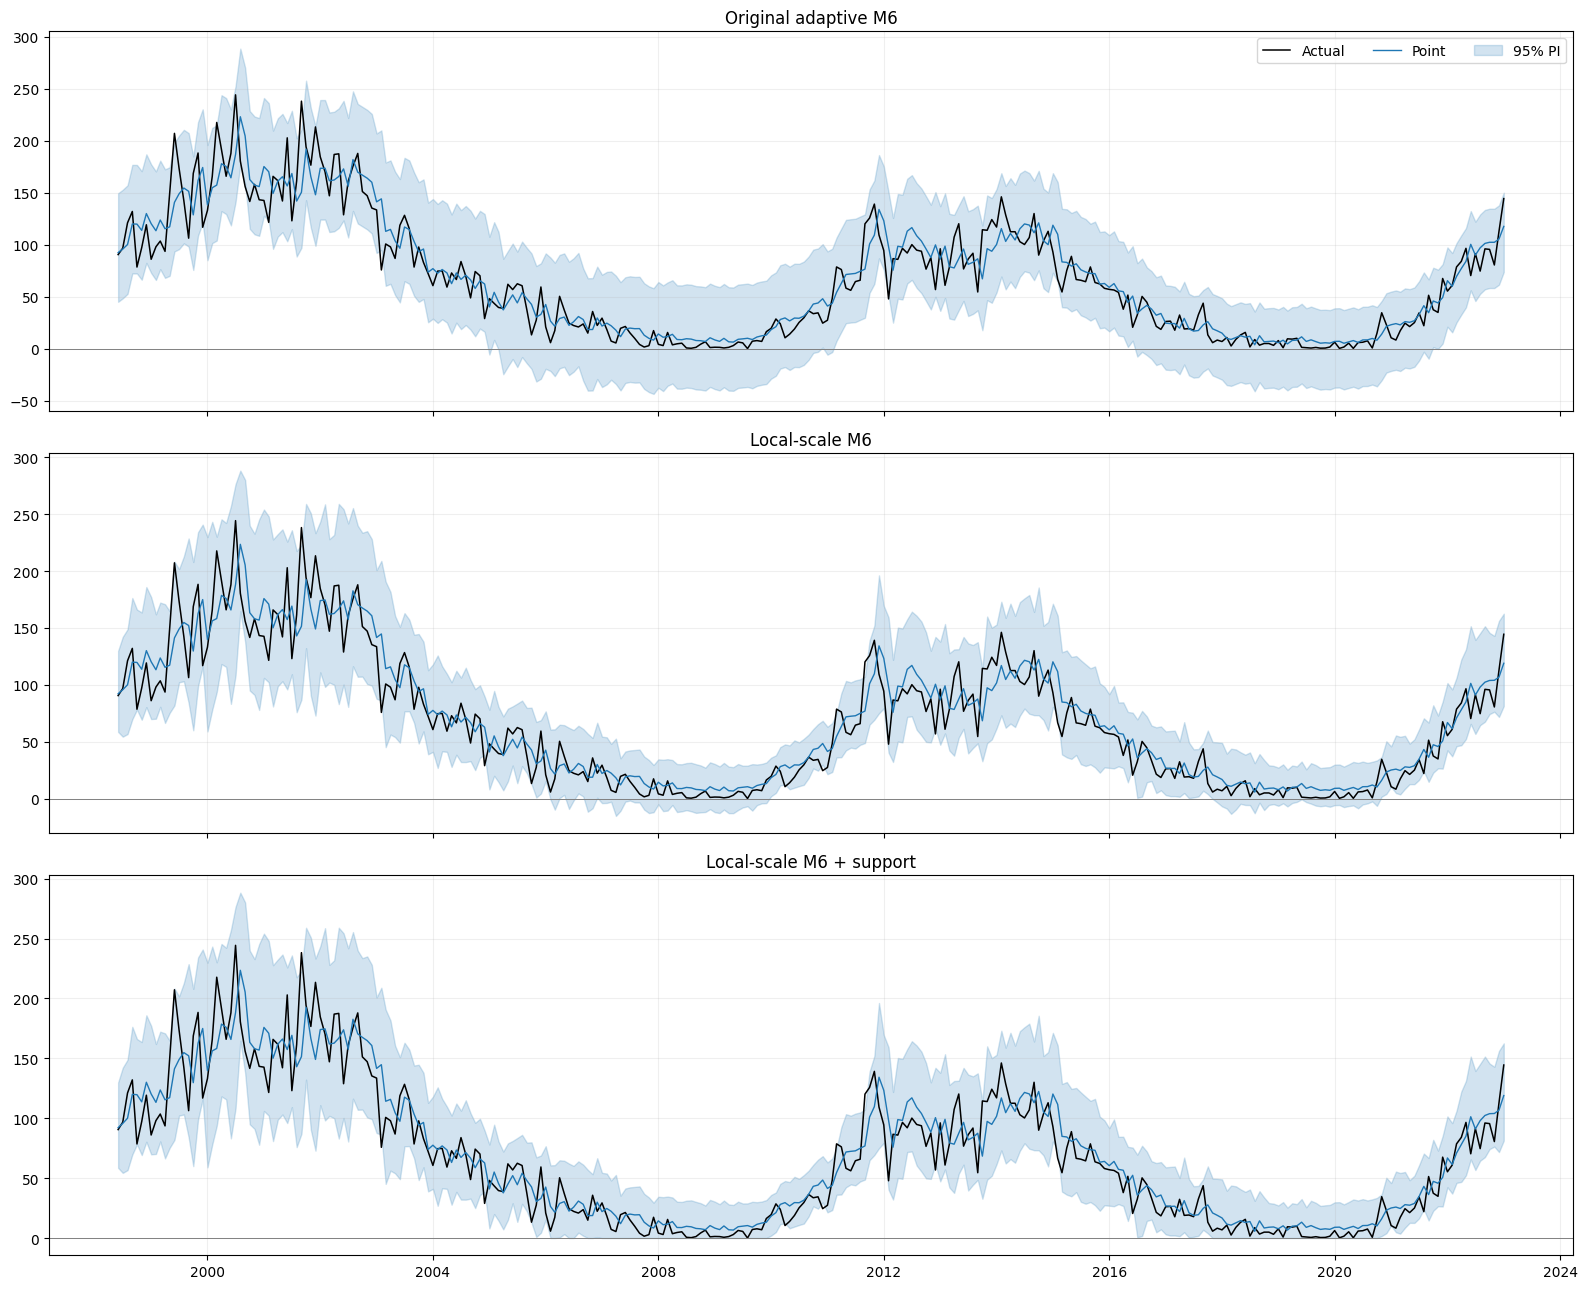

In [5]:
predictions=pd.concat([baseline,scaled.predictions.drop(columns='local_scale')],ignore_index=True)
fig,axes=plt.subplots(3,1,figsize=(16,13),sharex=True)
for ax,(method,g) in zip(axes,predictions.groupby('method',sort=False)):
    ax.plot(g.date,g.truth,color='black',lw=1.1,label='Actual'); ax.plot(g.date,g.point,color='tab:blue',lw=1,label='Point')
    ax.fill_between(g.date,g.lower,g.upper,color='tab:blue',alpha=.2,label='95% PI'); ax.axhline(0,color='gray',lw=.7); ax.set_title(method); ax.grid(alpha=.2)
axes[0].legend(ncol=3); fig.tight_layout(); plt.show()

In [6]:
activity=pd.cut(baseline.truth,[-np.inf,10,100,np.inf],labels=['low (y<=10)','middle (10<y<=100)','high (y>100)'])
rows=[]
for method,g in predictions.groupby('method',sort=False):
    for level in activity.cat.categories:
        z=g.loc[np.asarray(activity==level)]; m=metrics(z); m.update(activity=str(level),n=len(z)); rows.append(m)
pd.DataFrame(rows)[['method','activity','n','coverage','mean_width','interval_score','negative_lower_rate']]

,method,activity,n,coverage,mean_width,interval_score,negative_lower_rate
0,Original adaptive M6,low (y<=10),62,1.000000,87.938501,87.938501,1.000000
1,Original adaptive M6,middle (10<y<=100),158,0.987342,96.931313,102.646957,0.468354
2,Original adaptive M6,high (y>100),76,0.921053,107.881081,133.070775,0.000000
3,Local-scale M6,low (y<=10),62,1.000000,41.069566,41.069566,0.983871
4,Local-scale M6,middle (10<y<=100),158,0.943038,66.878918,79.904442,0.107595
5,Local-scale M6,high (y>100),76,0.960526,121.055621,136.025212,0.000000
6,Local-scale M6 + support,low (y<=10),62,1.000000,33.727231,33.727231,0.000000
7,Local-scale M6 + support,middle (10<y<=100),158,0.943038,66.143101,79.168624,0.000000
8,Local-scale M6 + support,high (y>100),76,0.960526,121.055621,136.025212,0.000000
